# Import Libraries

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

# Load Datasets

In [4]:
df = pd.read_csv("C:/Users/Chetan/ML Project/CREDIT CARD FRAUD DETECTION/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Data Understanding

In [5]:
print("Shape of dataset:", df.shape)

print("\nData Info:")

df.info()

Shape of dataset: (284807, 31)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20  

In [6]:
print("\nMissing Values")

print(df.isnull().sum())


Missing Values
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [7]:
print("\nClass Distribution")

print(df['Class'].value_counts())


Class Distribution
Class
0    284315
1       492
Name: count, dtype: int64


# Data Visualization

Class Distribution

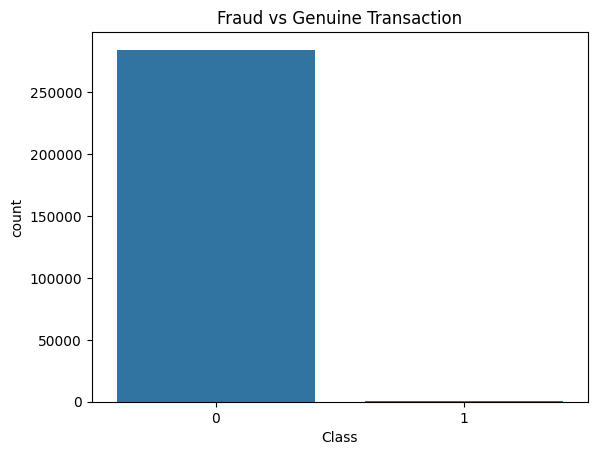

In [8]:
sns.countplot(x = 'Class', data = df)
plt.title("Fraud vs Genuine Transaction")
plt.show()

Amount Distribution 

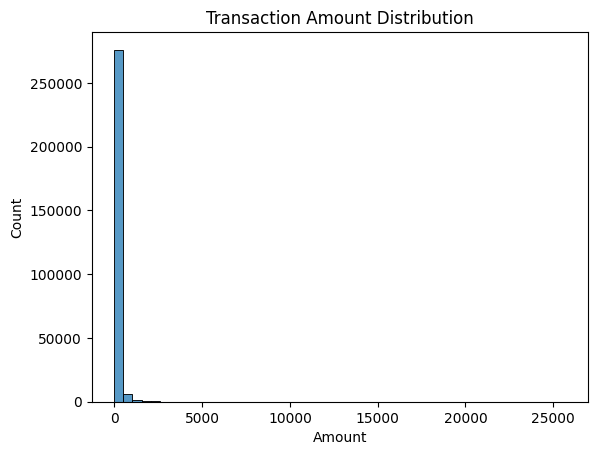

In [9]:
sns.histplot(df['Amount'], bins = 50)
plt.title("Transaction Amount Distribution")
plt.show()

# Data Preprocessing

Normalize 'Amount'

In [10]:
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])

Drop 'Time' column 

In [11]:
df = df.drop(['Time'], axis = 1)
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403,0


# Split Features and Target

In [12]:
X = df.drop('Class', axis = 1)
y = df['Class']

In [13]:
print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (284807, 29)
Target Shape: (284807,)


# Handle Class Imbalanced (SMOTE)

In [14]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state = 42)

In [15]:
print("Before SMOTE:", np.bincount(y))
X_resampled, y_resampled = smote.fit_resample(X, y)
print('After SMOTE:', np.bincount(y_resampled))

Before SMOTE: [284315    492]
After SMOTE: [284315 284315]


# Train Test Split


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size = 0.2, random_state = 42)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (454904, 29)
Testing Data: (113726, 29)


# Train Logistic Regression

In [17]:
lr_model = LogisticRegression(max_iter = 1000)
lr_model.fit(X_train, y_train)

print("Logistic Regression Trained")

Logistic Regression Trained


# Train Random Forest

In [18]:
rf_model = RandomForestClassifier(n_estimators = 20, random_state = 40)

rf_model.fit(X_train, y_train)

,n_estimators,20
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Evaluation Function

In [19]:
def evaluate_model(model, name):
    y_pred = model.predict(X_test)
    print(f"\n = = = = = {name} = = = = =")
    print("\nConfusion Matrix:")
    print(confusion_matrix, (y_test, y_pred))

    print("\nClassification Report")
    print(classification_report, (y_test, y_pred))

# Evaluate Models

In [20]:
evaluate_model(lr_model, "Logistic Regression")
evaluate_model(rf_model, "Random Forest")


 = = = = = Logistic Regression = = = = =

Confusion Matrix:
<function confusion_matrix at 0x000001D568B570A0> (437378    1
504222    1
4794      0
388411    1
424512    1
         ..
172633    0
183013    0
484066    1
426713    1
272068    0
Name: Class, Length: 113726, dtype: int64, array([1, 1, 0, ..., 1, 1, 0], shape=(113726,)))

Classification Report
<function classification_report at 0x000001D568B7C160> (437378    1
504222    1
4794      0
388411    1
424512    1
         ..
172633    0
183013    0
484066    1
426713    1
272068    0
Name: Class, Length: 113726, dtype: int64, array([1, 1, 0, ..., 1, 1, 0], shape=(113726,)))

 = = = = = Random Forest = = = = =

Confusion Matrix:
<function confusion_matrix at 0x000001D568B570A0> (437378    1
504222    1
4794      0
388411    1
424512    1
         ..
172633    0
183013    0
484066    1
426713    1
272068    0
Name: Class, Length: 113726, dtype: int64, array([1, 1, 0, ..., 1, 1, 0], shape=(113726,)))

Classification Report
<functio

# Conclusion

Conclusion

- Dataset was highly imbalanced
- SMOTE helped balance the data 
- Random Forest performed better than Logistic Regression 
- Recall is the most important metric in fraud detection.

# Save Model

In [21]:
import joblib 

joblib.dump(rf_model, "fraud_model.pkl")

print("Model saved Successfully!")

Model saved Successfully!


# Test Prediction

In [22]:
sample = X_test.iloc[0].values.reshape(1, -1)
prediction = rf_model.predict(sample)

print("prediction:", "Fraud" if prediction[0] == 1 else "Genuine")

prediction: Fraud


c:\Users\Chetan\ML Project\CREDIT CARD FRAUD DETECTION\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
